In [18]:
from IPython.display import Image, display
import operator
from typing import Annotated, List, Literal, TypedDict
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langchain_core.messages import (
    HumanMessage,
    AIMessage,
    ToolMessage,
    SystemMessage,
)
from langgraph.graph.message import add_messages
from typing_extensions import Annotated
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode

In [4]:

from models import model
question =" sum of one and one, answer :"
response = model.invoke(question)
print(response)


content='2' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 24, 'total_tokens': 41, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 11, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-ultra-550b-a55b:free', 'system_fingerprint': None, 'id': 'gen-1786005563-vRPOqICIFRJEtD4VdmCV', 'finish_reason': 'stop', 'logprobs': None} id='lc_run--019fd63a-25a8-7561-86e0-b9362c1925a7-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 24, 'output_tokens': 17, 'total_tokens': 41, 'input_token_details': {'audio': 0, 'cache_read': 0}, 

In [20]:
#tool

@tool
def search_file(file_name):
    """Return the absolute path of the first file matching file_name (without extension)."""
    for root, dirs, files in os.walk(os.path.expanduser('~/documents')):
        for file in files:
            file_search_name, _ =os.path.splitext(file)
            if file_search_name == file_name:
                return os.path.join(root, file)
    return None
@tool
def read_file(file_path):
    ''' return content in file '''
    with open(file_path, 'r', encoding= "utf-8") as f:
        content = f.read()
    return content

tools = [search_file, read_file]
    

In [21]:
class State(TypedDict):
    messages : Annotated[List[str], add_messages]


In [37]:
def search_model(state: State) -> Command[Literal["s_tool",END]]:
    model_with_search = model.bind_tools([search_file])
    response = model_with_search.invoke(state['messages'])
    print("Đã tìm ")
    if response.tool_calls:
        next_node = "s_tool"
    else:
        next_node = END
    return Command(
    update= {
        'messages': [response]
    },
    goto= next_node
    )
def read_model(state: State) -> Command[Literal["r_tool",END]]:
    model_with_read = model.bind_tools([read_file])
    response = model_with_read.invoke(state['messages'])
    print('Đã đọc.')
    if response.tool_calls:
        next_node = "r_tool"
    else:
        next_node = END
    return Command(
    update={
        'messages': [response]
        },
    goto= next_node
    )
    
search_node= ToolNode([search_file])
read_node = ToolNode([read_file])
def summarize_node(state: State):
    SYSTEM_PROMPT = """
You are an AI assistant that can use tools and summarize tool results.

Your task is to analyze the conversation history,
especially the latest ToolMessage, and produce a clear final response.

When a ToolMessage is present:
- Read the tool output carefully.
- Extract the important information.
- Do not invent information.
"""
    msg = [
        SystemMessage(content=SYSTEM_PROMPT),
        *state["messages"]
    ]
    response= model.invoke(msg)
    return { 'messages': [response]}    


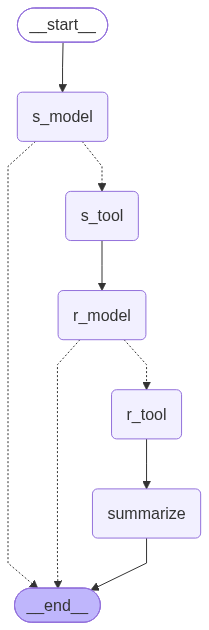

In [38]:
builder = StateGraph(State)
#ADD NODE
builder.add_node('s_model', search_model)
builder.add_node('r_model', read_model)
builder.add_node('s_tool', search_node)
builder.add_node('r_tool', read_node)
builder.add_node('summarize', summarize_node)

builder.add_edge(START, 's_model')
builder.add_edge('s_tool','r_model')
builder.add_edge('r_tool', 'summarize')
builder.add_edge('summarize', END)

graph = builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
user_prompt = input("prompt: ")
intitial_state= State(
    messages= [ HumanMessage(user_prompt)]
)



prompt:  summarize file "text" in documents 


In [39]:
result= graph.invoke(intitial_state)
print(result)

Đã tìm 
Đã đọc.
{'messages': [HumanMessage(content='summarize file "text" in documents ', additional_kwargs={}, response_metadata={}, id='93054495-ec20-4a48-ab30-0223915047b7'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 71, 'prompt_tokens': 281, 'total_tokens': 352, 'completion_tokens_details': {'accepted_prediction_tokens': None, 'audio_tokens': 0, 'reasoning_tokens': 47, 'rejected_prediction_tokens': None, 'image_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0, 'cache_write_tokens': 0, 'video_tokens': 0}, 'cost': 0, 'is_byok': False, 'cost_details': {'upstream_inference_cost': 0, 'upstream_inference_prompt_cost': 0, 'upstream_inference_completions_cost': 0}}, 'model_provider': 'openai', 'model_name': 'nvidia/nemotron-3-ultra-550b-a55b:free', 'system_fingerprint': None, 'id': 'gen-1786037772-nUh3Yfs5ECk7z5l1r5LT', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019fd825-